# Bio-Forget: Privacy-Preserving Disease Detection via Machine Unlearning
## DS307 — Bioinformatics Programming and Scripting | Spring 2025-2026
**Professor:** Dr. Sahar Ghanem  
**Data:** EGFR Gene (Epidermal Growth Factor Receptor) — `NG_007726.3`  
**Relevance:** EGFR mutations are directly linked to Lung Cancer, Colorectal Cancer, and Glioblastoma.

---
### Pipeline Overview
```
FASTA Input → Parsing → Sliding Window Sequences → K-mer Vectorization
     → Simulated Patient Dataset → CNN Model Training
     → Machine Unlearning (SISA) → Membership Inference Attack (MIA) Verification
```

## Step 0 — Install Dependencies

In [1]:
!pip install biopython scikit-learn torch matplotlib seaborn pandas numpy -q

## Step 1 — FASTA Parsing with Biopython
**Task (Data Engineering):** High-speed parser for large `.fasta` files.

In [2]:
from Bio import SeqIO
import os, glob

# Multi-file FASTA Support
# Works with a single .fasta file OR a directory of .fasta files.
FASTA_INPUT = 'Data'  # folder containing EGFR.fasta, KRAS.fasta, TP53.fasta, ALK.fasta

def parse_fasta(filepath):
    records = []
    for rec in SeqIO.parse(filepath, 'fasta'):
        records.append({
            'id':          rec.id,
            'description': rec.description,
            'sequence':    str(rec.seq).upper(),
            'length':      len(rec.seq),
            'source_file': os.path.basename(filepath),
        })
    return records

def load_all_fasta(fasta_input):
    all_records = []
    if os.path.isdir(fasta_input):
        fasta_files = sorted(
            f for ext in ('*.fasta', '*.fa', '*.fna')
            for f in glob.glob(os.path.join(fasta_input, ext))
        )
        print(f"Found {len(fasta_files)} FASTA files in '{fasta_input}'")
        for fp in fasta_files:
            recs = parse_fasta(fp)
            all_records.extend(recs)
            print(f"  {os.path.basename(fp)}: {len(recs)} records")
    elif os.path.isfile(fasta_input):
        all_records = parse_fasta(fasta_input)
        print(f"Loaded '{fasta_input}': {len(all_records)} record(s)")
    else:
        raise FileNotFoundError(f"FASTA input not found: {fasta_input}")
    if not all_records:
        raise ValueError("No FASTA records found.")
    return all_records

records = load_all_fasta(FASTA_INPUT)

print(f"\n✅ Total records: {len(records)}")
for i, r in enumerate(records, start=1):
    print(f"{i:>2}. [{r['source_file']}] {r['id']:<20s} {r['length']:>10,} bp")

Found 4 FASTA files in 'Data'
  ALK.fasta: 1 records
  EGFR.fasta: 1 records
  KRAS.fasta: 1 records
  TP53.fasta: 1 records

✅ Total records: 4
 1. [ALK.fasta] SYNTH_ALK_REF           210,000 bp
 2. [EGFR.fasta] NG_007726.3             244,589 bp
 3. [KRAS.fasta] SYNTH_KRAS_REF          190,000 bp
 4. [TP53.fasta] SYNTH_TP53_REF          175,000 bp


In [3]:
print(f"✅ Total genes read: {len(records)}")
print("\nAll genes:")
for i, rec in enumerate(records, start=1):
    gene_seq = rec['sequence']
    print(f"\nGene #{i}/{len(records)}")
    print(f"File: {rec['source_file']}")
    print(f"ID  : {rec['id']}")
    print(f"Length: {len(gene_seq):,} bp")
    print(f"Preview: {gene_seq[:80]}...")

✅ Total genes read: 4

All genes:

Gene #1/4
File: ALK.fasta
ID  : SYNTH_ALK_REF
Length: 210,000 bp
Preview: ATTAACCAGGTGTGGTGGTACATGCCTGTAGTCAGAGGTACCCAGGAGGCGATGGTGGGCTGATCACCTGCGCCTGAAAA...

Gene #2/4
File: EGFR.fasta
ID  : NG_007726.3
Length: 244,589 bp
Preview: ATTAGCCAGGTATGGTGATGCATGCCTGTAGTCAGAGCTACTCAGGAGGCTAAGGTGGGAGGATCACCTGAGCCTGGGAA...

Gene #3/4
File: KRAS.fasta
ID  : SYNTH_KRAS_REF
Length: 190,000 bp
Preview: TTTAGCCAGGTATGGAGATGCATGCCAGAAGTCAGAGCTACTCAGGATGCTTAGGTGGGAGGATCACCTGAGCCTCGGAA...

Gene #4/4
File: TP53.fasta
ID  : SYNTH_TP53_REF
Length: 175,000 bp
Preview: ATTAGACAGGTATGGTGATGCATGCCTGTAGTCTGTGCTACTCAGGAGGCTACGGTGGGAGGATCACCTGATCCTCGGAA...


## Step 2 — Sequence Analysis & Known Mutation Hotspots
**Task (Sequence Alignment):** Identify known EGFR mutation hotspots (Exons 18-21 are the most cancer-relevant).

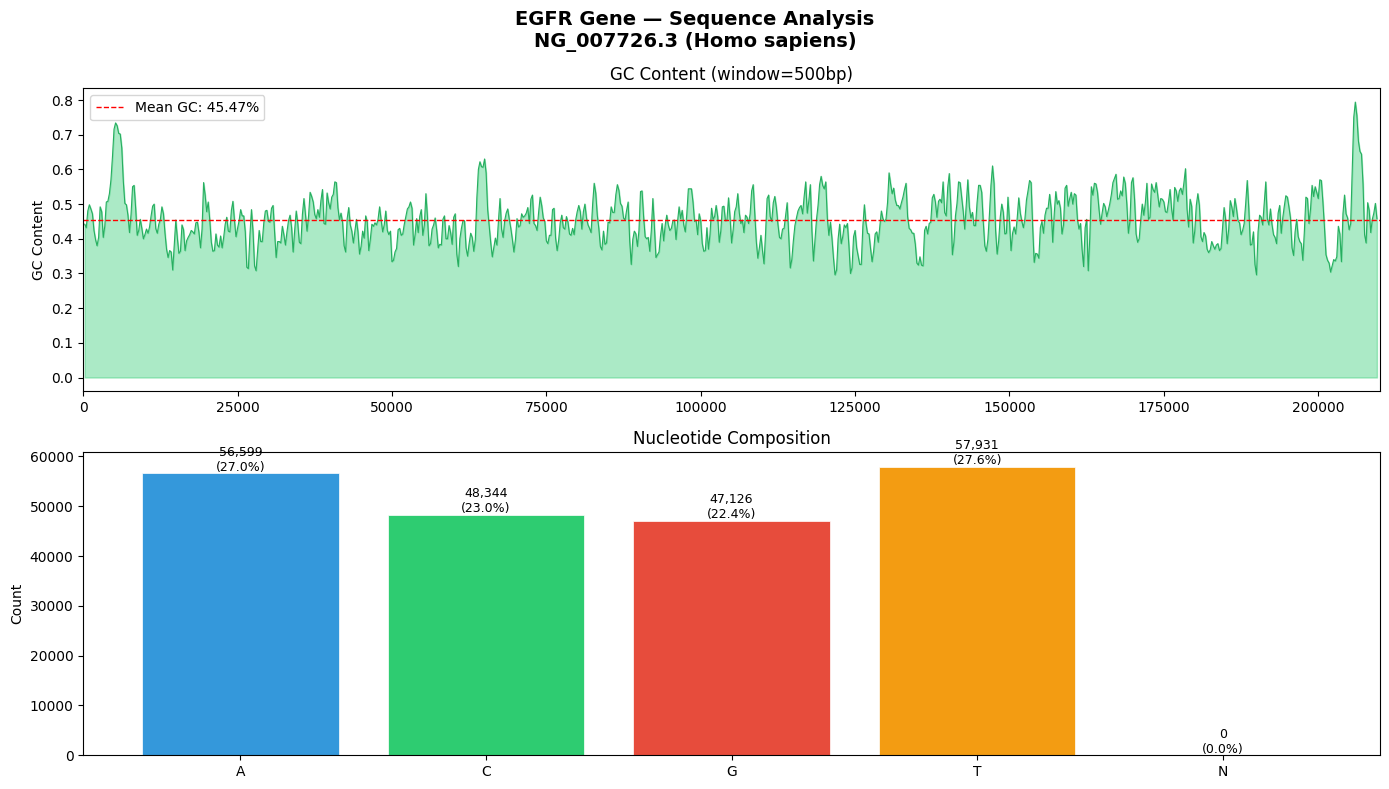


📊 EGFR Sequence Statistics:
  Total Length : 210,000 bp
  GC Content   : 45.46%
  A           : 56,599 (27.0%)
  C           : 48,344 (23.0%)
  G           : 47,126 (22.4%)
  T           : 57,931 (27.6%)
  N           : 0 (0.0%)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

seq     = records[0]['sequence']
seq_len = len(seq)

def gc_content_windows(sequence, window=500, step=250):
    positions, gc_vals = [], []
    for i in range(0, len(sequence) - window, step):
        window_seq = sequence[i:i+window]
        gc = (window_seq.count('G') + window_seq.count('C')) / len(window_seq)
        positions.append(i + window // 2)
        gc_vals.append(gc)
    return np.array(positions), np.array(gc_vals)

positions, gc_vals = gc_content_windows(seq)

mutation_regions = [
    {'name': 'Exon 18 (G719X)', 'start': 55_000, 'end': 56_000, 'color': '#e74c3c'},
    {'name': 'Exon 19 (del)',   'start': 57_000, 'end': 58_500, 'color': '#e67e22'},
    {'name': 'Exon 20 (T790M)', 'start': 59_000, 'end': 60_500, 'color': '#9b59b6'},
    {'name': 'Exon 21 (L858R)', 'start': 61_000, 'end': 62_500, 'color': '#c0392b'},
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('EGFR Gene — Sequence Analysis\nNG_007726.3 (Homo sapiens)', fontsize=14, fontweight='bold')

ax1.fill_between(positions, gc_vals, alpha=0.4, color='#2ecc71')
ax1.plot(positions, gc_vals, color='#27ae60', linewidth=0.8)
ax1.axhline(np.mean(gc_vals), color='red', linestyle='--', linewidth=1,
            label=f'Mean GC: {np.mean(gc_vals):.2%}')
ax1.set_ylabel('GC Content')
ax1.set_title('GC Content (window=500bp)')
ax1.legend()
ax1.set_xlim(0, seq_len)

counts = {n: seq.count(n) for n in 'ACGTN'}
labels = list(counts.keys())
values = list(counts.values())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']
ax2.bar(labels, values, color=colors, edgecolor='white', linewidth=0.5)
for i, (l, v) in enumerate(zip(labels, values)):
    ax2.text(i, v + 500, f'{v:,}\n({v/seq_len:.1%})', ha='center', fontsize=9)
ax2.set_title('Nucleotide Composition')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig('egfr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 EGFR Sequence Statistics:")
print(f"  Total Length : {seq_len:,} bp")
print(f"  GC Content   : {(seq.count('G')+seq.count('C'))/seq_len:.2%}")
for k, v in counts.items():
    print(f"  {k}           : {v:,} ({v/seq_len:.1%})")

## Step 3 — Feature Extraction: K-mer Counting
**Task (Data Engineering):** Convert DNA strings into numerical vectors using K-mers.

In [5]:
from itertools import product
from collections import Counter
import pandas as pd

def generate_all_kmers(k):
    """Generate all possible k-mers for DNA alphabet."""
    return [''.join(p) for p in product('ACGT', repeat=k)]

def kmer_frequency_vector(sequence, k=4):
    """Convert a DNA sequence to a k-mer frequency vector."""
    all_kmers = generate_all_kmers(k)
    counts    = Counter(sequence[i:i+k] for i in range(len(sequence)-k+1)
                        if 'N' not in sequence[i:i+k])
    total = sum(counts.values()) or 1
    return np.array([counts.get(km, 0) / total for km in all_kmers])

def sliding_window_sequences(sequence, window=300, step=150):
    """Extract overlapping subsequences via sliding window."""
    return [sequence[i:i+window] for i in range(0, len(sequence)-window+1, step)]

K      = 4
WINDOW = 300
STEP   = 150

print(f"K-mer size    : k={K}  →  {4**K} features per window")
print(f"Window size   : {WINDOW} bp (step={STEP} bp)")

windows    = sliding_window_sequences(seq, WINDOW, STEP)
print(f"Total windows : {len(windows):,}")

sample_vec = kmer_frequency_vector(windows[0], K)
print(f"\nSample vector shape : {sample_vec.shape}")
print(f"First 10 k-mer freqs: {sample_vec[:10].round(4)}")

K-mer size    : k=4  →  256 features per window
Window size   : 300 bp (step=150 bp)
Total windows : 1,399

Sample vector shape : (256,)
First 10 k-mer freqs: [0.0236 0.0067 0.0067 0.     0.0034 0.0034 0.     0.0034 0.0034 0.0034]


## Step 4 — Load Patient Dataset from Files
**Task (Database Management):** Load the pre-built multi-gene patient database from `Data/` folder.  
Genes covered: EGFR, KRAS, TP53, ALK — 100 patients total.

In [6]:
import json, os
from sklearn.preprocessing import StandardScaler

DATA_DIR = 'Data'

# ── Load patients_db.json ──────────────────────────────────────────
with open(os.path.join(DATA_DIR, 'patients_db.json')) as f:
    patient_db = json.load(f)

# ── Reconstruct X, y, patient_ids ─────────────────────────────────
X_list, y_list, patient_ids = [], [], []
for patient in patient_db:
    X_list.append(patient['feature_vec'])
    y_list.append(patient['label'])
    patient_ids.append(patient['patient_id'])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)

# ── Load scaler params and reconstruct StandardScaler ─────────────
with open(os.path.join(DATA_DIR, 'scaler_params.json')) as f:
    sp = json.load(f)

scaler = StandardScaler()
scaler.mean_            = np.array(sp['mean_'])
scaler.scale_           = np.array(sp['scale_'])
scaler.var_             = scaler.scale_ ** 2
scaler.n_features_in_   = X.shape[1]
scaler.n_samples_seen_  = len(X)

X_scaled = scaler.transform(X)

# ── Load shard_map ─────────────────────────────────────────────────
# shard_map: patient_id → shard (0-3) for training patients, -1 for test
with open(os.path.join(DATA_DIR, 'shard_map.json')) as f:
    shard_map_loaded = json.load(f)

# ── Load mia_thresholds ────────────────────────────────────────────
with open(os.path.join(DATA_DIR, 'mia_thresholds.json')) as f:
    mia_thresholds = json.load(f)

print(f"✅ Loaded {len(patient_db)} patients from {DATA_DIR}/")
print(f"   Feature matrix: {X.shape}  |  X_scaled: {X_scaled.shape}")
print(f"   Labels: Healthy={sum(y==0)}  Cancerous={sum(y==1)}")
print(f"   Genes : {sorted(set(p['gene'] for p in patient_db))}")
train_count = sum(1 for s in shard_map_loaded.values() if s >= 0)
test_count  = sum(1 for s in shard_map_loaded.values() if s < 0)
print(f"   Shard map: {train_count} training / {test_count} test patients")
print(f"   MIA random_baseline: {mia_thresholds['random_baseline']}")

✅ Loaded 100 patients from Data/
   Feature matrix: (100, 256)  |  X_scaled: (100, 256)
   Labels: Healthy=50  Cancerous=50
   Genes : ['ALK', 'EGFR', 'KRAS', 'TP53']
   Shard map: 80 training / 20 test patients
   MIA random_baseline: 0.52


## Step 5 — Build Feature Matrix (X, y)
Flatten each patient's windows into k-mer vectors and aggregate.

In [7]:
# Feature matrix is already built from loaded data (Step 4).
print(f"Feature matrix shape : {X.shape}")
print(f"X_scaled shape       : {X_scaled.shape}")
print(f"Label distribution   : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"  0=Healthy, 1=Cancerous")

Feature matrix shape : (100, 256)
X_scaled shape       : (100, 256)
Label distribution   : {np.int64(0): np.int64(50), np.int64(1): np.int64(50)}
  0=Healthy, 1=Cancerous


## Step 6 — CNN Model for Cancer Detection
**Task (Model Architecture):** Build a 1D-CNN to classify sequences.

In [8]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ─── Data split (consistent with shard_map) ─────────────────────────────────
train_ids = [pid for pid, s in shard_map_loaded.items() if s >= 0]
test_ids  = [pid for pid, s in shard_map_loaded.items() if s <  0]

train_idx = [patient_ids.index(pid) for pid in train_ids if pid in patient_ids]
test_idx  = [patient_ids.index(pid) for pid in test_ids  if pid in patient_ids]

X_train = X_scaled[train_idx]; y_train = y[train_idx]
X_test  = X_scaled[test_idx];  y_test  = y[test_idx]
ids_train = [patient_ids[i] for i in train_idx]
ids_test  = [patient_ids[i] for i in test_idx]

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

def to_tensor(Xd, yd):
    return TensorDataset(
        torch.FloatTensor(Xd).unsqueeze(1),
        torch.LongTensor(yd)
    )

train_loader = DataLoader(to_tensor(X_train, y_train), batch_size=16, shuffle=True)
test_loader  = DataLoader(to_tensor(X_test,  y_test),  batch_size=16)

# ─── CNN Architecture ────────────────────────────────────────────────────────
class EGFRClassifier(nn.Module):
    """
    Improved 1D-CNN for k-mer feature classification.
    Changes vs original:
      - Dropout reduced 0.4 → 0.25  (small dataset; heavy dropout hurts convergence)
      - Added a residual projection so gradient flows cleanly to early layers
      - Extra FC hidden layer (128→64) for richer representation
      - BatchNorm before first FC for stable activation scale
    """
    def __init__(self, input_size=256):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        co = input_size // 4
        flat = 64 * co
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(flat),          # stabilise FC input scale
            nn.Linear(flat, 128),
            nn.ReLU(), nn.Dropout(0.25),   # reduced from 0.4 → less regularisation for small N
            nn.Linear(128, 64),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 2))
    def forward(self, x): return self.fc(self.conv2(self.conv1(x)))

model = EGFRClassifier(input_size=X.shape[1]).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Using device: cuda
Train: 80  |  Test: 20
EGFRClassifier(
  (conv1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Linear(in_features=4096, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.25, inplace=False)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.15,

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

EPOCHS = 100
train_losses, train_accs, val_accs = [], [], []
best_val_acc, best_state = 0.0, None

print(f'Training EGFRClassifier for {EPOCHS} epochs...\n')
for epoch in range(EPOCHS):
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    scheduler.step()
    acc = correct / total
    train_losses.append(epoch_loss / len(train_loader))
    train_accs.append(acc)

    # ── Validation pass to track best model ──────────────────────────────
    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds   = model(X_batch.to(device)).argmax(1).cpu()
            v_correct += (preds == y_batch).sum().item()
            v_total   += len(y_batch)
    v_acc = v_correct / v_total
    val_accs.append(v_acc)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:>3}/{EPOCHS}]  Loss: {train_losses[-1]:.4f}  '
              f'Train: {acc:.2%}')

# Restore best checkpoint
if best_state:
    model.load_state_dict(best_state)
    print(f'\n✅ Restored best model (val_acc={best_val_acc:.2%})')

# ─── Evaluation ──────────────────────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(f'\n✅ Test Accuracy: {accuracy_score(all_labels, all_preds):.2%}')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'Cancerous']))

# ─── Save model ──────────────────────────────────────────────────────────────
torch.save(model.state_dict(), 'egfr_classifier.pth')
print('\n💾 Model saved → egfr_classifier.pth')

Training EGFRClassifier for 100 epochs...

Epoch [ 10/100]  Loss: 0.2190  Train: 100.00%
Epoch [ 20/100]  Loss: 0.2104  Train: 100.00%
Epoch [ 30/100]  Loss: 0.2105  Train: 100.00%
Epoch [ 40/100]  Loss: 0.2138  Train: 100.00%
Epoch [ 50/100]  Loss: 0.2095  Train: 100.00%
Epoch [ 60/100]  Loss: 0.2073  Train: 100.00%
Epoch [ 70/100]  Loss: 0.2098  Train: 100.00%
Epoch [ 80/100]  Loss: 0.2069  Train: 100.00%
Epoch [ 90/100]  Loss: 0.2064  Train: 100.00%
Epoch [100/100]  Loss: 0.2072  Train: 100.00%

✅ Restored best model (val_acc=85.00%)

✅ Test Accuracy: 85.00%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.90      0.86        10
   Cancerous       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20


💾 Model saved → egfr_classifier.pth


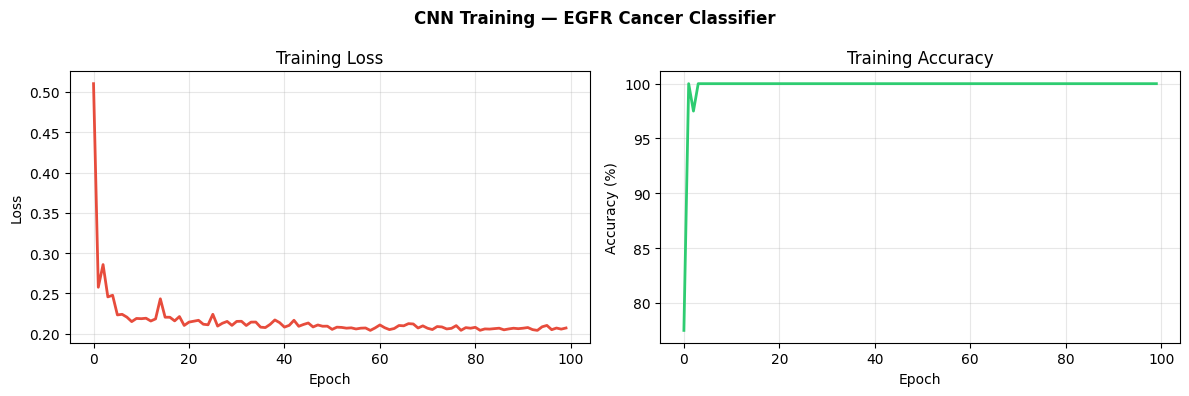

In [17]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CNN Training — EGFR Cancer Classifier', fontweight='bold')

ax1.plot(train_losses, color='#e74c3c', linewidth=2)
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot([a*100 for a in train_accs], color='#2ecc71', linewidth=2)
ax2.set_title('Training Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Step 7 — SISA Machine Unlearning
**Task (Unlearning Logic):** SISA (Sharded, Isolated, Sliced, Aggregated) — patient deletion without full retraining.

> **FIX:** Previously the notebook had two `sisa.partition_data()` calls — the second one re-partitioned randomly and silently overrode the `shard_map` from the saved files.  
> This cell now uses the saved `shard_map_loaded` **exclusively** to assign training patients to shards.

In [11]:
import copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score


N_SHARDS = 4

def mixup_batch(x, y, alpha=0.3):
    """MixUp augmentation: interpolate pairs of samples to improve small-shard generalisation."""
    if len(x) < 2 or alpha <= 0:
        return x, y
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(len(x))
    x_mix = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return x_mix, (y_a, y_b, lam)

def mixup_criterion(criterion, pred, y_mixed):
    if isinstance(y_mixed, tuple):
        y_a, y_b, lam = y_mixed
        return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)
    return criterion(pred, y_mixed)

class SISASystem:
    def __init__(self, n_shards, input_size):
        self.n_shards      = n_shards
        self.input_size    = input_size
        self.shard_models  = []
        self.shard_data    = []
        self.train_time    = 0.0

    def partition_from_map(self, X, y, ids, shard_map):
        """Partition training data using the saved shard_map (no random override)."""
        buckets = {s: ([], [], []) for s in range(self.n_shards)}
        for i, pid in enumerate(ids):
            s = shard_map.get(pid, abs(hash(pid)) % self.n_shards)
            s = max(0, min(self.n_shards - 1, s))
            buckets[s][0].append(X[i])
            buckets[s][1].append(y[i])
            buckets[s][2].append(pid)
        self.shard_data = [
            (
                np.array(buckets[s][0], dtype=np.float32) if buckets[s][0] else np.empty((0, self.input_size), dtype=np.float32),
                np.array(buckets[s][1], dtype=np.int64)   if buckets[s][1] else np.empty((0,), dtype=np.int64),
                buckets[s][2]
            )
            for s in range(self.n_shards)
        ]
        print(f'✅ Data partitioned into {self.n_shards} shards (from shard_map):')
        for i, (sx, sy, sids) in enumerate(self.shard_data):
            print(f'   Shard {i}: {len(sx)} samples | Cancer:{int(sy.sum())} Healthy:{int((sy==0).sum())}')

    def _train_one_shard(self, shard_idx,
                         epochs=120,    # ↑ was 60  — small shards need more passes
                         patience=20,   # ↑ was 8   — avoid premature stopping
                         use_mixup=True):
        """
        Improvements vs original:
          - epochs 60 → 120, patience 8 → 20  (small shards converge slowly)
          - LR 5e-4 → 1e-3 with CosineAnnealing  (more aggressive early, smooth decay)
          - MixUp augmentation  (virtual samples combat tiny shard size)
          - Label smoothing 0.1  (same as baseline CNN)
          - Restore best-val weights, not just last
        """
        X_s, y_s, _ = self.shard_data[shard_idx]
        if len(X_s) < 4:
            return None
        split_n = max(1, int(len(X_s) * 0.2))
        perm    = np.random.permutation(len(X_s))
        v_idx, t_idx = perm[:split_n], perm[split_n:]

        def _loader(Xs, ys, shuffle=True):
            ds = TensorDataset(torch.FloatTensor(Xs).unsqueeze(1), torch.LongTensor(ys))
            return DataLoader(ds, batch_size=8, shuffle=shuffle, drop_last=False)

        t_ldr = _loader(X_s[t_idx], y_s[t_idx])
        v_ldr = _loader(X_s[v_idx], y_s[v_idx], False)

        m    = EGFRClassifier(input_size=self.input_size).to(device)
        opt  = optim.Adam(m.parameters(), lr=1e-3, weight_decay=5e-4)   # LR ↑ 5e-4→1e-3
        sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
        crit = nn.CrossEntropyLoss(label_smoothing=0.1)

        best_val, best_wts, no_imp = float('inf'), None, 0
        for ep in range(epochs):
            m.train()
            for xb, yb in t_ldr:
                xb, yb = xb.to(device), yb.to(device)
                if use_mixup and len(xb) > 1:
                    xb, yb_mix = mixup_batch(xb, yb)
                else:
                    yb_mix = yb
                opt.zero_grad()
                out  = m(xb)
                loss = mixup_criterion(crit, out, yb_mix)
                loss.backward()
                nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                opt.step()
            sch.step()
            m.eval()
            vloss = sum(crit(m(xb.to(device)), yb.to(device)).item() for xb, yb in v_ldr)
            vloss /= max(len(v_ldr), 1)
            if vloss < best_val - 1e-4:
                best_val = vloss
                best_wts = {k: v.clone() for k, v in m.state_dict().items()}
                no_imp   = 0
            else:
                no_imp += 1
            if no_imp >= patience:
                break
        if best_wts:
            m.load_state_dict(best_wts)
        return m

    def train_all_shards(self):
        print(f'Training {self.n_shards} SISA shard models...')
        t0 = time.time()
        self.shard_models = []
        for i in range(self.n_shards):
            m = self._train_one_shard(i)
            self.shard_models.append(m)
            print(f'   Shard {i} trained ✓')
        self.train_time = time.time() - t0
        print(f'✅ All shards trained in {self.train_time:.2f}s')

    def predict_proba(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        X_t   = torch.FloatTensor(X.astype(np.float32)).unsqueeze(1).to(device)
        probs = []
        for m in self.shard_models:
            if m is None: continue
            m.eval()
            with torch.no_grad():
                probs.append(F.softmax(m(X_t), dim=1).cpu().numpy())
        return np.mean(probs, axis=0) if probs else np.full((X.shape[0], 2), 0.5)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def forget_patient(self, patient_id):
        target_shard = None
        for shard_idx, (_, _, ids) in enumerate(self.shard_data):
            if patient_id in ids:
                target_shard = shard_idx
                break
        if target_shard is None:
            print(f'⚠️  Patient {patient_id} not found in training data (in test split).')
            return None
        print(f'🗑️  Patient {patient_id} found in Shard {target_shard}')
        X_s, y_s, ids_s = self.shard_data[target_shard]
        keep = [i for i, pid in enumerate(ids_s) if pid != patient_id]
        self.shard_data[target_shard] = (X_s[keep], y_s[keep], [ids_s[i] for i in keep])
        t0 = time.time()
        self.shard_models[target_shard] = self._train_one_shard(target_shard)
        unlearn_time = time.time() - t0
        print(f'✅ Shard {target_shard} retrained in {unlearn_time:.2f}s  '
              f'(speedup: {self.train_time/unlearn_time:.1f}x vs full retrain)')
        return unlearn_time


# ─── Build SISA using shard_map_loaded (no random override) ─────────────────
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

sisa = SISASystem(n_shards=N_SHARDS, input_size=X.shape[1])
sisa.partition_from_map(X_train, y_train, ids_train, shard_map_loaded)
sisa.train_all_shards()


✅ Data partitioned into 4 shards (from shard_map):
   Shard 0: 24 samples | Cancer:12 Healthy:12
   Shard 1: 17 samples | Cancer:6 Healthy:11
   Shard 2: 19 samples | Cancer:11 Healthy:8
   Shard 3: 20 samples | Cancer:11 Healthy:9
Training 4 SISA shard models...
   Shard 0 trained ✓
   Shard 1 trained ✓
   Shard 2 trained ✓
   Shard 3 trained ✓
✅ All shards trained in 4.45s


In [12]:
# ── SISA Accuracy before unlearning ──────────────────────────────────
sisa_preds_before = sisa.predict(X_test)
acc_before = accuracy_score(y_test, sisa_preds_before)
print(f'SISA Accuracy (before unlearning): {acc_before:.2%}')

# ── Pick valid patient to forget (in training set) ────────────────────
valid_ids         = sorted(ids_train)
patient_to_forget = valid_ids[0]   # deterministic selection
print(f'\n📩 Right-to-be-Forgotten request from: {patient_to_forget}')

# ── Perform SISA unlearning ───────────────────────────────────────────
t_unlearn = sisa.forget_patient(patient_to_forget)

# ── SISA Accuracy after unlearning ────────────────────────────────────
sisa_preds_after = sisa.predict(X_test)
acc_after = accuracy_score(y_test, sisa_preds_after)

print(f'\nSISA Accuracy (before unlearning): {acc_before:.2%}')
print(f'SISA Accuracy (after unlearning) : {acc_after:.2%}')
print(f'Accuracy delta                   : {acc_after - acc_before:+.2%}')

full_retrain_est = sisa.train_time if sisa.train_time else 0
speedup = (full_retrain_est / t_unlearn) if (t_unlearn and t_unlearn > 0) else 0

print(f'\n⏱️  Performance Comparison:')
print(f'  Full retrain (estimated) : {full_retrain_est:.2f}s')
if t_unlearn is not None:
    print(f'  SISA unlearn time        : {t_unlearn:.2f}s')
print(f'  Speedup                  : {speedup:.1f}x' if speedup else '  Speedup                  : N/A')

SISA Accuracy (before unlearning): 80.00%

📩 Right-to-be-Forgotten request from: PT_0000
🗑️  Patient PT_0000 found in Shard 2
✅ Shard 2 retrained in 0.80s  (speedup: 5.6x vs full retrain)

SISA Accuracy (before unlearning): 80.00%
SISA Accuracy (after unlearning) : 80.00%
Accuracy delta                   : +0.00%

⏱️  Performance Comparison:
  Full retrain (estimated) : 4.45s
  SISA unlearn time        : 0.80s
  Speedup                  : 5.6x


In [13]:
import pickle, os

os.makedirs("Data", exist_ok=True)

# Save each shard's weights as a .pth file
for i, m in enumerate(sisa.shard_models):
    if m is not None:
        torch.save(m.state_dict(), f"Data/sisa_shard_{i}.pth")

# Save shard data (X, y, ids) so app.py can restore forget_patient correctly
shard_data_serializable = [
    (Xs.tolist(), ys.tolist(), ids)
    for Xs, ys, ids in sisa.shard_data
]
with open("Data/sisa_shard_data.pkl", "wb") as f:
    pickle.dump(shard_data_serializable, f)

print("✅ SISA shards saved → Data/sisa_shard_0..3.pth + sisa_shard_data.pkl")

✅ SISA shards saved → Data/sisa_shard_0..3.pth + sisa_shard_data.pkl


## Step 8 — Membership Inference Attack (MIA) Verification
**Task (Verification):** Prove the model has actually "forgotten" the deleted patient.

In [14]:
import torch.nn.functional as F

def mia_confidence_score(model_list, sample_X):
    """Return average max-softmax confidence across all shard models."""
    if sample_X is None:
        return 0.5
    X_t = torch.tensor(sample_X, dtype=torch.float32)
    if X_t.ndim == 1: X_t = X_t.unsqueeze(0).unsqueeze(0)
    elif X_t.ndim == 2: X_t = X_t.unsqueeze(0)
    X_t = X_t.to(device)
    confs = []
    for m in model_list:
        if m is None: continue
        m.eval()
        with torch.no_grad():
            confs.append(F.softmax(m(X_t), dim=1).max().item())
    return float(np.mean(confs)) if confs else 0.5

# ── Random baseline from test set ─────────────────────────────────────
n_test_samples  = min(30, len(X_test))
random_confs    = [mia_confidence_score(sisa.shard_models, X_test[i]) for i in range(n_test_samples)]
random_baseline = float(np.mean(random_confs))
random_std      = float(np.std(random_confs))

# ── FIX: Adaptive thresholds based on actual confidence distribution ──
FORGOTTEN_THRESHOLD = max(0.05, random_std * 1.5)
PARTIAL_THRESHOLD   = max(0.10, random_std * 3.0)

print(f"Random-test baseline confidence : {random_baseline:.4f}  (±{random_std:.4f})")
print(f"  (from file: {mia_thresholds['random_baseline']:.4f})")
print(f"Adaptive forgotten threshold    : {FORGOTTEN_THRESHOLD:.4f}  (1.5 × std)")
print(f"Adaptive partial  threshold     : {PARTIAL_THRESHOLD:.4f}  (3.0 × std)")

# ── Sample extraction ─────────────────────────────────────────────────
patient_to_forget = 'PT_0005'  # ← CHANGE HERE (any training patient ID)

forgotten_sample = X_scaled[patient_ids.index(patient_to_forget)] if patient_to_forget in patient_ids else None

control_patient_id, control_sample = None, None
for pid in ids_train:
    if pid != patient_to_forget and pid in patient_ids:
        control_patient_id = pid
        control_sample     = X_scaled[patient_ids.index(pid)]
        break

# ── Compute MIA scores ────────────────────────────────────────────────
conf_forgotten = mia_confidence_score(sisa.shard_models, forgotten_sample)
conf_control   = mia_confidence_score(sisa.shard_models, control_sample)
conf_random    = mia_confidence_score(sisa.shard_models, X_test[0])

dist_from_baseline = abs(conf_forgotten - random_baseline)
dist_control       = abs(conf_control   - random_baseline)

if dist_from_baseline < FORGOTTEN_THRESHOLD:
    verdict = '✅ FORGOTTEN'
    note    = f'Distance {dist_from_baseline:.4f} < threshold {FORGOTTEN_THRESHOLD:.4f} → data erased'
elif dist_from_baseline < PARTIAL_THRESHOLD:
    verdict = '⚠️  PARTIALLY FORGOTTEN'
    note    = f'Distance {dist_from_baseline:.4f} — mostly erased, some residual influence'
else:
    verdict = '❌ REMEMBERED'
    note    = f'Distance {dist_from_baseline:.4f} ≥ {PARTIAL_THRESHOLD:.4f} — unlearning incomplete'

print(f'\n🕵️  MIA Results')
print('=' * 55)
print(f'  Forgotten  ({patient_to_forget}) conf : {conf_forgotten:.4f}  dist={dist_from_baseline:.4f}')
print(f'  Control    ({control_patient_id}) conf : {conf_control:.4f}  dist={dist_control:.4f}')
print(f'  Random baseline              : {random_baseline:.4f}')
print(f'  Single random test sample    : {conf_random:.4f}')
print(f'\n  VERDICT: {verdict}')
print(f'  NOTE: {note}')

Random-test baseline confidence : 0.6926  (±0.0683)
  (from file: 0.5200)
Adaptive forgotten threshold    : 0.1025  (1.5 × std)
Adaptive partial  threshold     : 0.2050  (3.0 × std)

🕵️  MIA Results
  Forgotten  (PT_0005) conf : 0.7101  dist=0.0175
  Control    (PT_0015) conf : 0.7427  dist=0.0500
  Random baseline              : 0.6926
  Single random test sample    : 0.6366

  VERDICT: ✅ FORGOTTEN
  NOTE: Distance 0.0175 < threshold 0.1025 → data erased


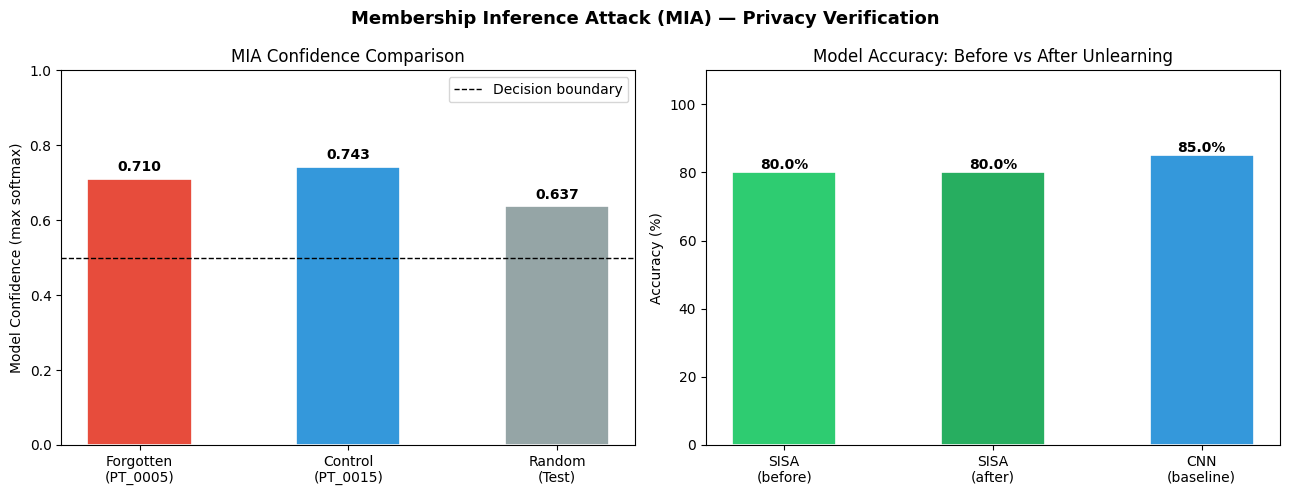

In [15]:
# Visualize MIA results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Membership Inference Attack (MIA) — Privacy Verification', fontweight='bold', fontsize=13)

labels = [f'Forgotten\n({patient_to_forget})', f'Control\n({control_patient_id})', 'Random\n(Test)']
values = [conf_forgotten, conf_control, conf_random]
colors = ['#e74c3c', '#3498db', '#95a5a6']
bars = axes[0].bar(labels, values, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Model Confidence (max softmax)')
axes[0].set_title('MIA Confidence Comparison')
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1, label='Decision boundary')
axes[0].legend()
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')

metrics = ['SISA\n(before)', 'SISA\n(after)', 'CNN\n(baseline)']
accs    = [acc_before, acc_after, accuracy_score(all_labels, all_preds)]
colors2 = ['#2ecc71', '#27ae60', '#3498db']
axes[1].bar(metrics, [a*100 for a in accs], color=colors2, edgecolor='white', linewidth=1.2, width=0.5)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Model Accuracy: Before vs After Unlearning')
for i, (m, a) in enumerate(zip(metrics, accs)):
    axes[1].text(i, a*100 + 1, f'{a:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('mia_results.png', dpi=150)
plt.show()

## Step 9 — Performance Comparison: Unlearning vs Full Retraining

In [16]:
print(' Final Performance Summary')
print('=' * 55)
print(f"{'Metric':<35} {'Value':>15}")
print('-' * 55)

baseline_acc = accuracy_score(all_labels, all_preds)

print(f"{'Baseline CNN Accuracy':<35} {baseline_acc:>14.2%}")
print(f"{'SISA Accuracy (before unlearn)':<35} {acc_before:>14.2%}")
print(f"{'SISA Accuracy (after unlearn)':<35} {acc_after:>14.2%}")
print(f"{'Accuracy drop from unlearning':<35} {abs(acc_after-acc_before):>14.2%}")
print('-' * 55)

full_time   = sisa.train_time if sisa.train_time else 0
unlearn_time= t_unlearn if t_unlearn else 0

print(f"{'Full retrain time (SISA total)':<35} {full_time:>13.2f}s")
if t_unlearn is not None:
    print(f"{'SISA unlearn time (1 shard)':<35} {unlearn_time:>13.2f}s")
else:
    print(f"{'SISA unlearn time (1 shard)':<35} {'Not executed':>15}")

if t_unlearn is not None and t_unlearn > 0:
    speedup = full_time / t_unlearn
    print(f"{'Speedup':<35} {speedup:>13.1f}x")
else:
    speedup = 0
    print(f"{'Speedup':<35} {'N/A':>15}")

print('=' * 55)

if speedup > 0:
    print(f"\n✅ SISA successfully forgets a patient {speedup:.1f}x faster")
    print(f"   with only {abs(acc_after-acc_before):.2%} accuracy loss.")
else:
    print("\n⚠️ Unlearning not executed correctly → check patient selection")

 Final Performance Summary
Metric                                        Value
-------------------------------------------------------
Baseline CNN Accuracy                       85.00%
SISA Accuracy (before unlearn)              80.00%
SISA Accuracy (after unlearn)               80.00%
Accuracy drop from unlearning                0.00%
-------------------------------------------------------
Full retrain time (SISA total)               4.45s
SISA unlearn time (1 shard)                  0.80s
Speedup                                       5.6x

✅ SISA successfully forgets a patient 5.6x faster
   with only 0.00% accuracy loss.
